# M6-B1 — Analyse de dérive

## 1. Exploration — distributions référence vs prod

In [1]:
# On charge les deux jeux de données
import pandas as pd
import matplotlib.pyplot as plt

ref = pd.read_csv("../data/reference_set.csv")   # données d'entraînement
prod = pd.read_csv("../data/prod_3months.csv")   # données de production

print("Référence :", ref.shape)
print("Production :", prod.shape)
ref.head()

Référence : (1500, 15)
Production : (3000, 16)


,loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,fico_range_low,revol_util,loan_status
0,7600,36 months,11.39,250.22,B,3 years,MORTGAGE,72500,Verified,debt_consolidation,13.12,1,725,48.0,Fully Paid
1,12800,60 months,14.74,302.77,C,10+ years,RENT,24500,Not Verified,debt_consolidation,28.10,0,692,50.5,Fully Paid
2,11400,36 months,7.06,352.31,A,3 years,MORTGAGE,112500,Verified,debt_consolidation,22.78,0,747,66.4,Fully Paid
3,40000,36 months,21.11,1509.26,E,8 years,RENT,71300,Verified,debt_consolidation,15.85,0,671,17.6,Fully Paid
4,12600,36 months,9.99,406.51,B,6 years,RENT,63500,Not Verified,debt_consolidation,9.31,1,733,39.0,Fully Paid


In [2]:
# On compte les valeurs manquantes AVANT de tracer quoi que ce soit :
# matplotlib refuse les NaN, et un dropna() silencieux réduirait l'effectif
# sans qu'on s'en rende compte. Un taux de manquants qui diffère entre
# référence et prod est lui-même un signal (ETL cassé, colonne plus alimentée).
num_cols = ["loan_amnt", "int_rate", "installment", "annual_inc",
            "dti", "delinq_2yrs", "fico_range_low", "revol_util"]

missing = pd.DataFrame({
    "n_missing_ref": ref[num_cols].isna().sum(),
    "%_missing_ref": (ref[num_cols].isna().mean() * 100).round(2),
    "n_missing_prod": prod[num_cols].isna().sum(),
    "%_missing_prod": (prod[num_cols].isna().mean() * 100).round(2),
})
missing

,n_missing_ref,%_missing_ref,n_missing_prod,%_missing_prod
loan_amnt,0,0.00,0,0.0
int_rate,0,0.00,0,0.0
installment,0,0.00,0,0.0
annual_inc,0,0.00,0,0.0
dti,0,0.00,0,0.0
delinq_2yrs,0,0.00,0,0.0
fico_range_low,0,0.00,0,0.0
revol_util,20,1.33,36,1.2


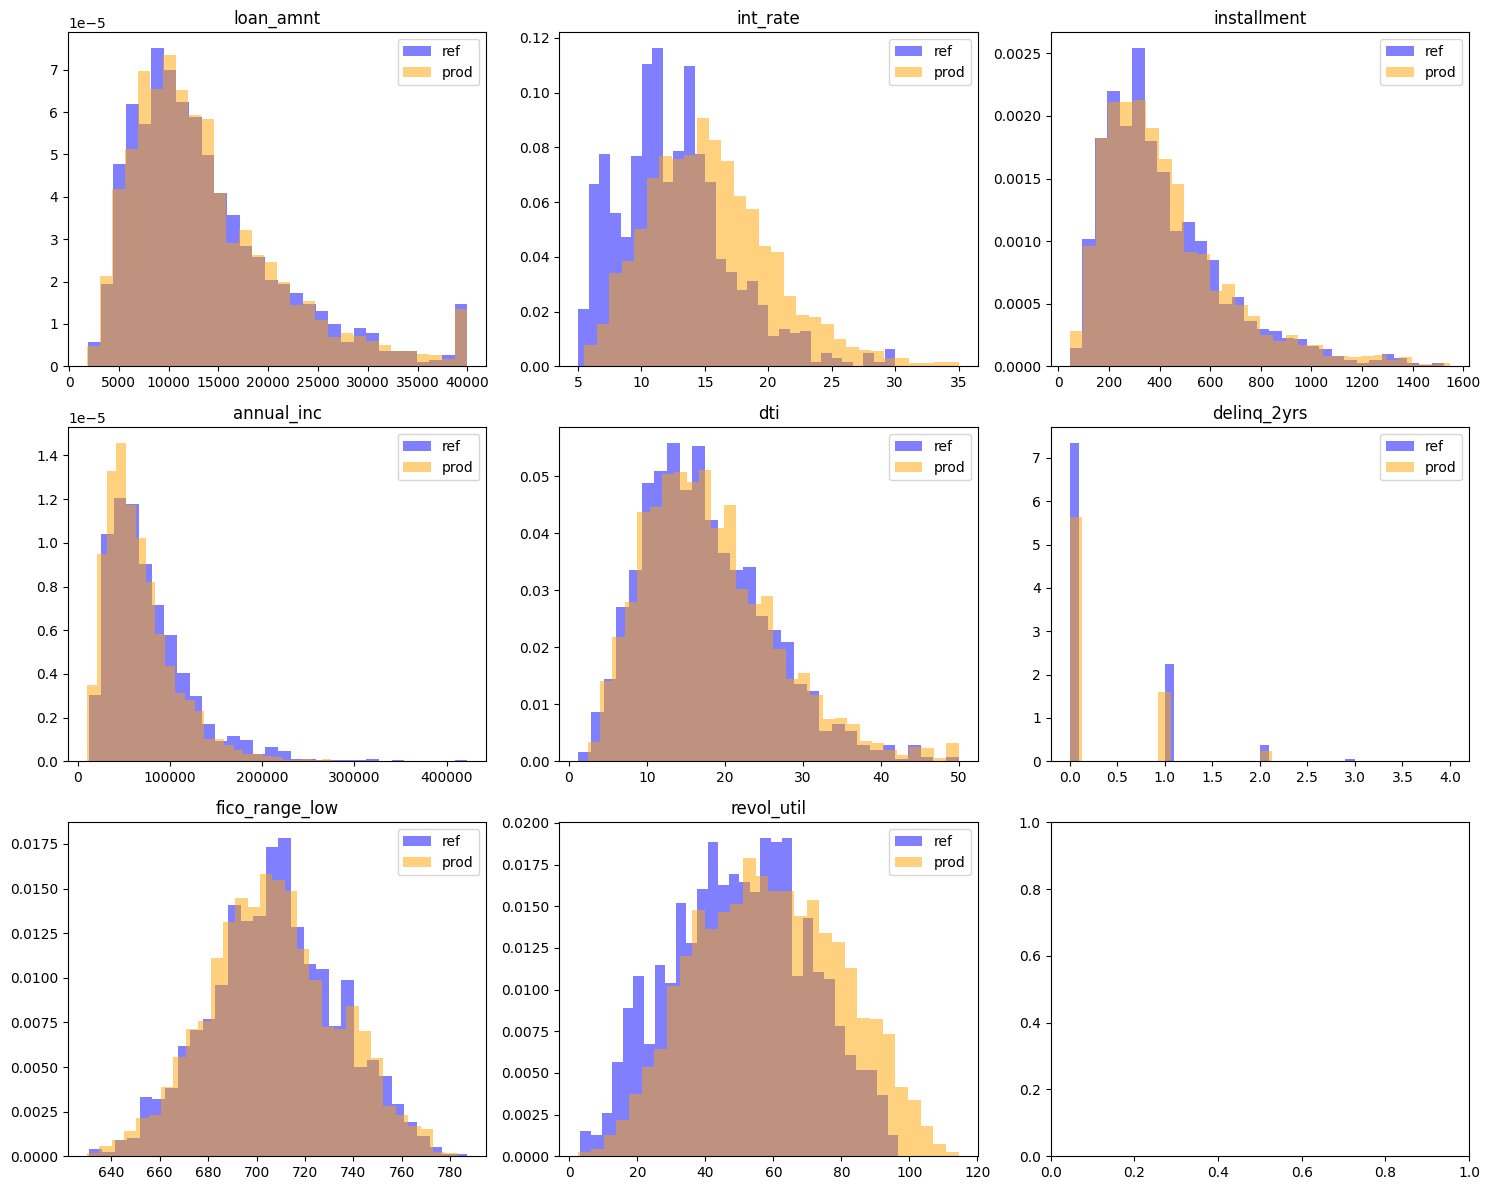

In [3]:
# Variables numériques : on superpose les histogrammes ref vs prod
# pour voir visuellement si les distributions ont bougé
num_cols = ["loan_amnt", "int_rate", "installment", "annual_inc",
            "dti", "delinq_2yrs", "fico_range_low", "revol_util"]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(ref[col].dropna(), bins=30, alpha=0.5, label="ref", color="blue", density=True)
    axes[i].hist(prod[col].dropna(), bins=30, alpha=0.5, label="prod", color="orange", density=True)
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.show()

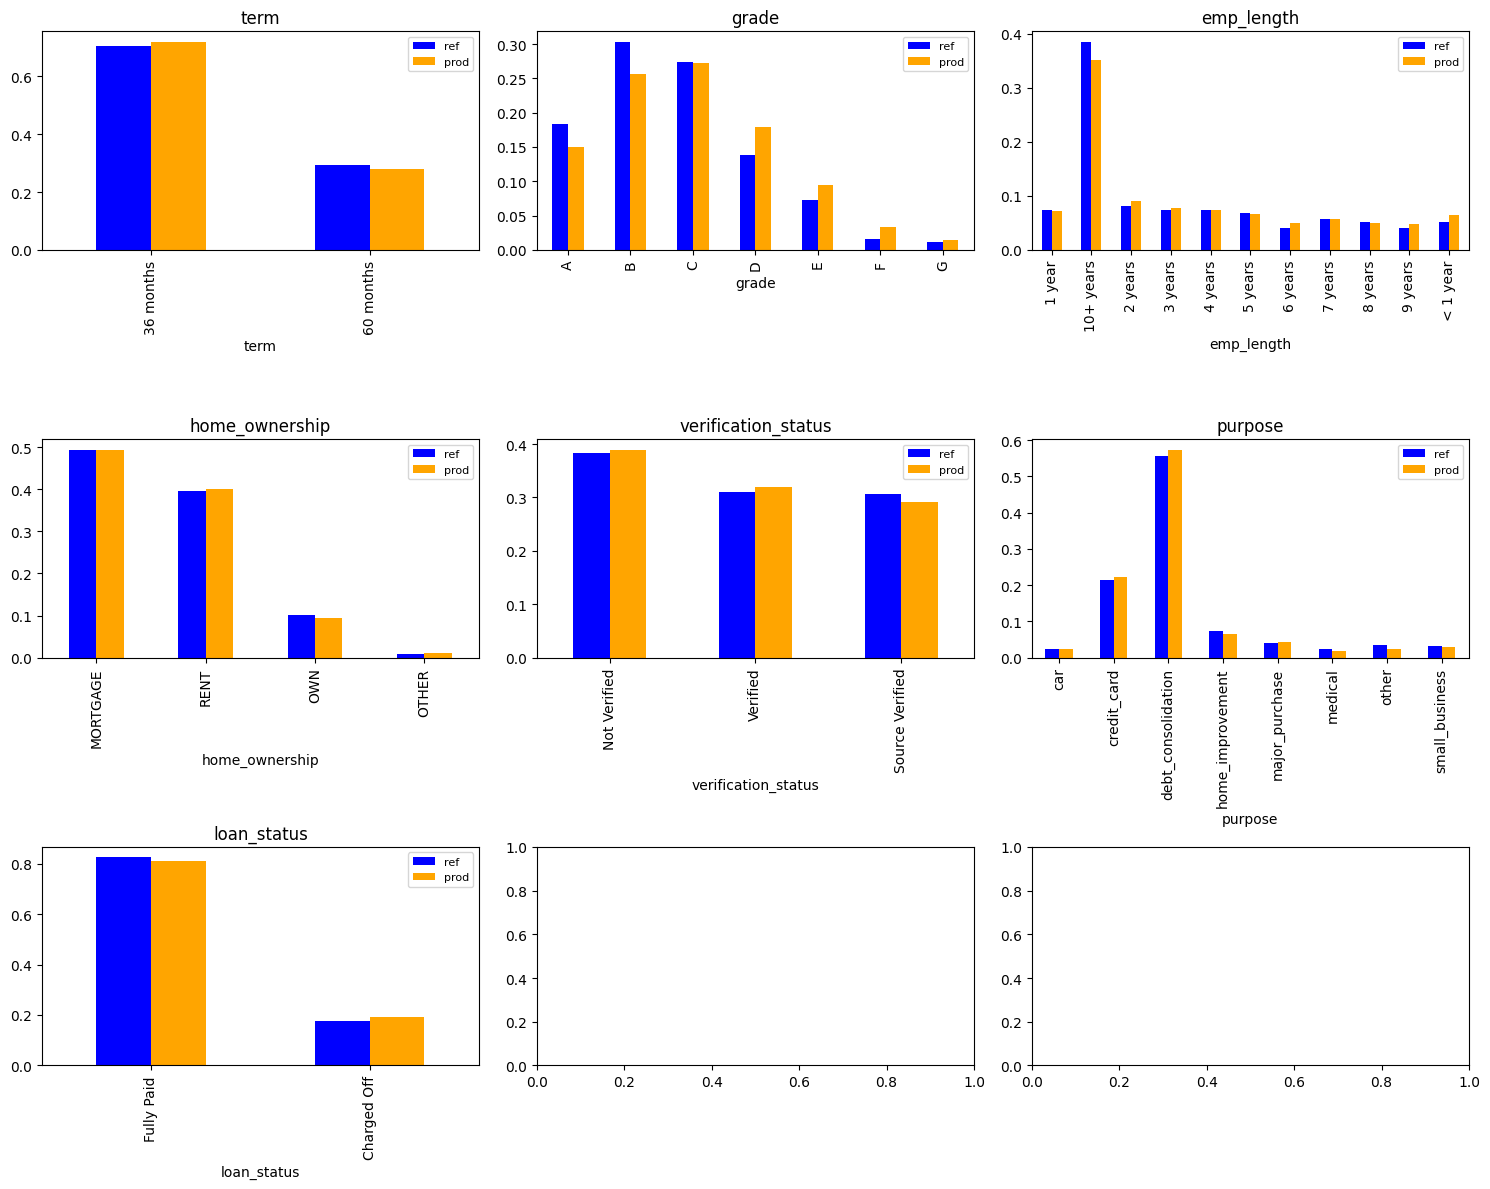

In [4]:
# Variables catégorielles : on compare les proportions de chaque modalité
cat_cols = ["term", "grade", "emp_length", "home_ownership",
            "verification_status", "purpose", "loan_status"]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ref_freq = ref[col].value_counts(normalize=True)
    prod_freq = prod[col].value_counts(normalize=True)
    df_freq = pd.DataFrame({"ref": ref_freq, "prod": prod_freq}).fillna(0)
    df_freq.plot.bar(ax=axes[i], color=["blue", "orange"])
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Lecture à l'œil (avant tout calcul)

1. Le taux d'intérêt (`int_rate`) est plus élevé en prod : en moyenne 15,50 %
   contre 12,61 % dans la référence, soit +2,9 points. C'est le décalage le
   plus net de toutes les variables — celui qu'on voit tout de suite sur le
   graphique.
2. La note de risque du dossier (`grade`) s'est dégradée : il y a moins de
   bons dossiers (note A, B) et plus de dossiers risqués (note D, E, F) en
   prod qu'avant. Logique : c'est justement cette note qui détermine le taux
   d'intérêt, donc ces deux changements racontent probablement la même
   chose — un seul phénomène (le mix de clients qui arrive a changé), pas
   deux problèmes séparés.
3. Le revenu annuel (`annual_inc`) a baissé d'environ 13 % en moyenne : les
   emprunteurs actuels gagnent moins que ceux de la référence.
4. Le taux d'utilisation du crédit renouvelable (`revol_util`) a augmenté
   (50,6 → 59,0). Sur les manquants : les deux jeux en ont (20/1500 = 1,33 %
   en référence, 36/3000 = 1,2 % en prod) — le taux est stable entre les
   deux, donc ce n'est pas un signal ETL en soi, juste une colonne
   partiellement incomplète dans les deux populations.
5. Le taux de défaut réel (la vraie proportion de mauvais payeurs) est passé
   de 17,5 % à 19,1 % — une hausse légère de 1,6 point, cohérente avec
   l'arrivée de dossiers plus risqués.

Ce qui n'a pas bougé : le montant emprunté, la mensualité, le taux
d'endettement, l'historique d'incidents de paiement, la durée du prêt,
l'ancienneté professionnelle, le type de logement, le mode de vérification,
le motif du prêt. Ces variables ont l'air stables, et aucune n'a de
manquants dans ni l'un ni l'autre jeu.

→ À confirmer statistiquement en section 2 : `int_rate`, `grade`,
`annual_inc` sont les features à surveiller en priorité. `revol_util` reste
à regarder (moyenne en hausse) mais son taux de manquants n'est plus un
signal d'alerte une fois compté correctement.


## 2. Détection statistique — PSI · KS · Chi²

In [5]:
import sys

sys.path.insert(0, "../src")
from drift_detection import PSI_DRIFT, PSI_STABLE, drift_report  # noqa: E402

# loan_status est la cible, pas une feature : on l'exclut de la détection de dérive
cat_cols_features = [c for c in cat_cols if c != "loan_status"]

drift_summary = drift_report(ref, prod, num_cols, cat_cols_features)
pd.set_option("display.float_format", lambda x: f"{x:.4g}")
drift_summary

,feature,type,psi,ks_pvalue,chi2_pvalue,verdict
0,grade,catégorielle,NaN,NaN,3.651e-07,dérive
1,int_rate,numérique,0.4436,4.628e-65,NaN,dérive
2,revol_util,numérique,0.1866,3.818e-20,NaN,suspect
3,purpose,catégorielle,NaN,NaN,0.1993,stable
4,term,catégorielle,NaN,NaN,0.3164,stable
5,emp_length,catégorielle,NaN,NaN,0.4916,stable
6,verification_status,catégorielle,NaN,NaN,0.5863,stable
7,home_ownership,catégorielle,NaN,NaN,0.6314,stable
8,annual_inc,numérique,0.06664,2.283e-09,NaN,stable
9,installment,numérique,0.01469,0.6626,NaN,stable


### Lecture du tableau

- **`int_rate`** confirme l'intuition de la section 1 : PSI = 0,44 (bien
  au-dessus du seuil 0,25) et KS quasi nul (4,6e-65) — signal fort et net,
  concordant sur les deux méthodes.
- **`grade`** : Chi² très significatif (p = 3,7e-7) — la redistribution des
  notes vue à l'œil est confirmée statistiquement.
- **`revol_util`** : PSI = 0,19, dans la zone "à investiguer" (0,10–0,25),
  pas encore "dérive forte". KS très significatif (p = 3,8e-20) — les deux
  signaux vont dans le même sens mais avec une ampleur modérée.
- **Piège évité — `annual_inc`** : PSI = 0,067 (stable) mais KS
  très significatif (p = 2,3e-9). C'est exactement l'avertissement du
  mini-cours : sur un échantillon de cette taille, KS peut détecter un écart
  réel mais de faible ampleur. On retient PSI pour juger l'**importance** du
  décalage, KS confirme juste qu'il est **statistiquement présent** — la
  conclusion, c'est "stable" (l'ampleur ne justifie pas une alerte), pas
  "dérive" sur la seule p-value.
- Le reste (`purpose`, `term`, `emp_length`, `verification_status`,
  `home_ownership`, `installment`, `dti`, `fico_range_low`, `loan_amnt`,
  `delinq_2yrs`) est stable sur les deux méthodes — cohérent avec la lecture
  à l'œil.

→ Deux features en dérive confirmée (`int_rate`, `grade`), une en zone
grise (`revol_util`). Exportées dans `drift_summary.md`.


In [6]:
INTERPRETATIONS = {
    "int_rate": (
        "PSI 0,44 très au-dessus du seuil de dérive forte (0,25), KS quasi "
        "nul (4,6e-65) : signal net et concordant sur les deux méthodes. "
        "Cohérent avec la redistribution de `grade` (le taux dépend de la "
        "note) — probablement le même phénomène de fond, pas deux dérives "
        "indépendantes."
    ),
    "revol_util": (
        "PSI 0,19, dans la zone à investiguer (0,10-0,25), pas encore une "
        "dérive forte. KS très significatif (3,8e-20) : l'écart est réel "
        "mais d'ampleur modérée. À surveiller, sans alerte immédiate."
    ),
    "annual_inc": (
        "PSI 0,067 (stable) mais KS très significatif (2,3e-9) : cas d'école "
        "du mini-cours — sur 1500 vs 3000 lignes, KS détecte un écart réel "
        "mais de faible ampleur. On retient le PSI pour juger l'importance : "
        "verdict stable, la baisse de revenu moyen ne suffit pas à elle "
        "seule à justifier une alerte."
    ),
    "installment": "PSI et KS tous deux non significatifs : aucun signal.",
    "dti": "PSI et KS tous deux non significatifs : aucun signal.",
    "fico_range_low": "PSI et KS tous deux non significatifs : aucun signal.",
    "loan_amnt": "PSI et KS tous deux non significatifs : aucun signal.",
    "delinq_2yrs": "PSI et KS tous deux non significatifs : aucun signal.",
    "grade": (
        "Chi² très significatif (p = 3,7e-7) : la redistribution vers des "
        "notes plus risquées (moins de A/B, plus de D/E/F) vue à l'œil en "
        "section 1 est confirmée statistiquement."
    ),
    "purpose": "Chi² non significatif (p = 0,20) : répartition des motifs stable.",
    "term": "Chi² non significatif (p = 0,32) : répartition des durées stable.",
    "emp_length": "Chi² non significatif (p = 0,49) : répartition stable.",
    "verification_status": "Chi² non significatif (p = 0,59) : répartition stable.",
    "home_ownership": "Chi² non significatif (p = 0,63) : répartition stable.",
}

lines = [
    "# Synthèse de dérive — `reference_set.csv` vs `prod_3months.csv`",
    "",
    "Repères PSI : < 0.10 signal faible · 0.10-0.25 à investiguer · > 0.25 signal fort.",
    "",
    "| Feature | Type | PSI | p-value (KS/Chi²) | Verdict | Interprétation |",
    "|---|---|---:|---:|---|---|",
]
for _, row in drift_summary.iterrows():
    pvalue = row["ks_pvalue"] if row["type"] == "numérique" else row["chi2_pvalue"]
    psi_str = f"{row['psi']:.3f}" if pd.notna(row["psi"]) else "—"
    lines.append(
        f"| `{row['feature']}` | {row['type']} | {psi_str} | {pvalue:.2g} "
        f"| {row['verdict']} | {INTERPRETATIONS[row['feature']]} |"
    )

with open("../drift_summary.md", "w", encoding="utf-8") as f:
    f.write("\n".join(lines) + "\n")

print("drift_summary.md écrit —", len(drift_summary), "features.")

drift_summary.md écrit — 14 features.


## 3. Calibration en exploitation

In [7]:
from calibration import expected_calibration_error, reliability_table

predictions = pd.read_csv("../data/predictions_log.csv", parse_dates=["timestamp"])
start = predictions["timestamp"].min()

# ⚠️ Fenêtres couvertes : la calibration exige les vrais labels, donc on
# compare toujours des périodes déjà passées, jamais "aujourd'hui".
early = predictions[predictions["timestamp"] < start + pd.Timedelta(weeks=4)]
late = predictions[predictions["timestamp"] >= start + pd.Timedelta(weeks=8)]

print(f"Semaines 1-4  : {early['timestamp'].min().date()} → {early['timestamp'].max().date()} ({len(early)} dossiers)")
print(f"Semaines 9-12 : {late['timestamp'].min().date()} → {late['timestamp'].max().date()} ({len(late)} dossiers)")

table_early = reliability_table(early["proba_default"], early["true_label"])
table_late = reliability_table(late["proba_default"], late["true_label"])
ece_early = expected_calibration_error(early["proba_default"], early["true_label"])
ece_late = expected_calibration_error(late["proba_default"], late["true_label"])

print(f"\nECE semaines 1-4  : {ece_early:.4f}")
print(f"ECE semaines 9-12 : {ece_late:.4f}")

Semaines 1-4  : 2026-03-02 → 2026-03-29 (1003 dossiers)
Semaines 9-12 : 2026-04-27 → 2026-05-24 (997 dossiers)

ECE semaines 1-4  : 0.2403
ECE semaines 9-12 : 0.3152


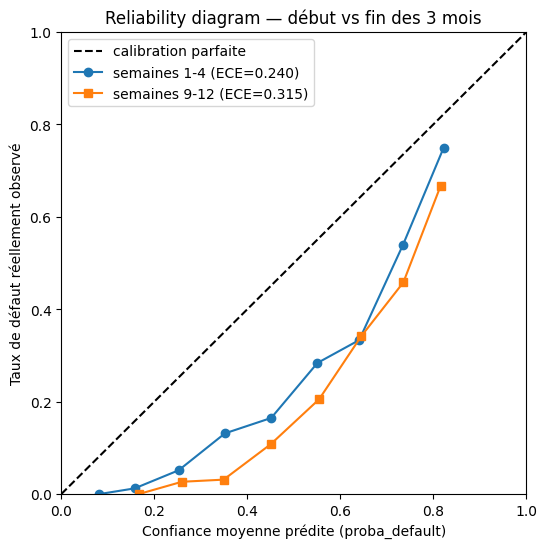

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", label="calibration parfaite")
ax.plot(table_early["confiance_moyenne"], table_early["taux_observe"], "o-", label=f"semaines 1-4 (ECE={ece_early:.3f})")
ax.plot(table_late["confiance_moyenne"], table_late["taux_observe"], "s-", label=f"semaines 9-12 (ECE={ece_late:.3f})")
ax.set_xlabel("Confiance moyenne prédite (proba_default)")
ax.set_ylabel("Taux de défaut réellement observé")
ax.set_title("Reliability diagram — début vs fin des 3 mois")
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.show()

### Lecture de la calibration

- Les deux courbes sont **sous la diagonale sur toute leur longueur** : le
  modèle est **sur-confiant** dès les semaines 1-4, pas seulement à la fin.
  Ex. sur les semaines 1-4, la tranche "confiance ≈ 0,55" n'observe en
  réalité que ~28 % de défauts ; sur les semaines 9-12, la tranche
  "confiance ≈ 0,55" n'en observe plus que ~21 %. L'écart se creuse.
- **ECE semaines 1-4 : 0,24 → ECE semaines 9-12 : 0,32.** La sur-confiance
  était déjà notable au début (ce n'est donc pas un phénomène nouveau créé
  par la dérive), et elle **s'est aggravée** sur la période.
- Fenêtre couverte : ces deux mesures portent sur des périodes déjà
  passées (2026-03-02 → 2026-03-29 et 2026-04-27 → 2026-05-24) — la
  calibration ne peut se lire qu'une fois les vrais labels connus, jamais
  en temps réel sur "aujourd'hui".
- Lien avec le drift (section 2) : une calibration qui se dégrade pendant
  que le mix de dossiers change (`int_rate`, `grade`) est cohérent avec un
  **data drift** — les entrées ont bougé, la confiance du modèle glisse
  avec elles, sans que ça prouve à ce stade que le modèle discrimine moins
  bien (ça, c'est l'AUC, tâche 6).


## 4. Performance dans le temps

In [9]:
# TODO


## 5. Diagnostic & recommandation

In [10]:
# TODO
